# Neighbourhood enrichment analysis of celltypes, using MuSpAn

In [1]:
import anndata as ad 
adata = ad.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")

In [2]:
replicates = {}
for rep in adata.obs.batch_key.unique():
    replicates[rep] = adata[adata.obs.batch_key == rep].copy()

In [3]:
#making MuSpAn domains
import muspan as ms
import numpy as np
import matplotlib.pyplot as plt

In [44]:
del rep_domains

In [ ]:
#dictionary of domains
rep_domains = {}
for name, rep in replicates.items():
    rep_domains[name] = ms.domain(f'{name}')

#add points, these will be in um if taken from xenium data
for name, domain in rep_domains.items():
    points = replicates[name].obsm['spatial']
    domain.add_points(points, 'cells')

#add labels
for name, domain in rep_domains.items():
    labels = replicates[name].obs.celltype_assignments.to_numpy()
    domain.add_labels('celltype_assignments', labels)

#estimate boundary using alphashape -- could also use compartment segmentations, similar results, given they are both defined by cell existence. 
for name, domain in rep_domains.items():
    domain.estimate_boundary(method = 'convex hull')
                             #alpha_shape_kwargs = {'alpha':15})

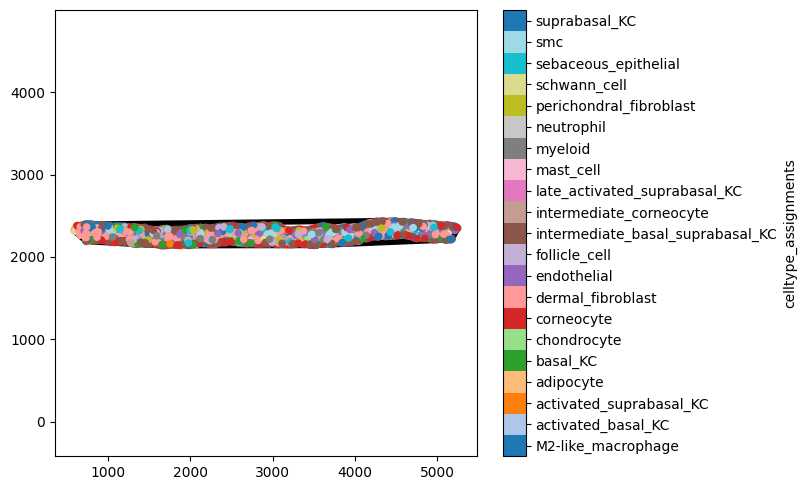

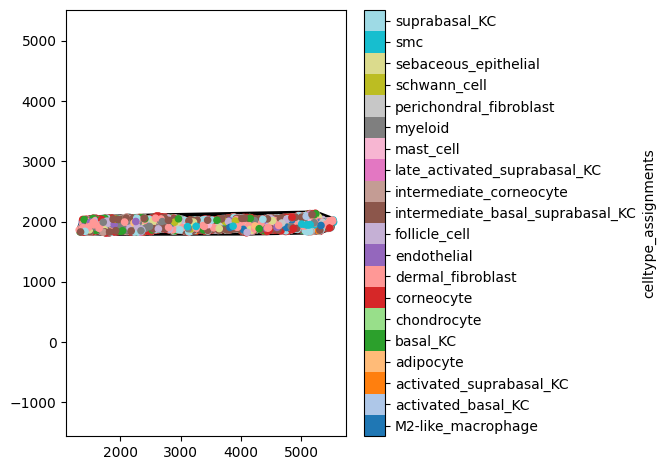

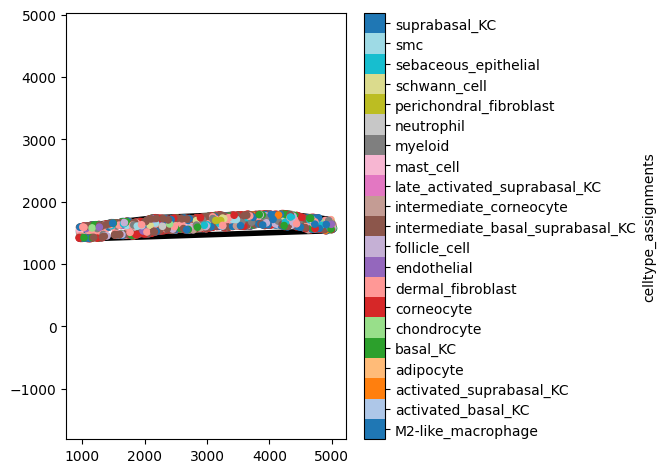

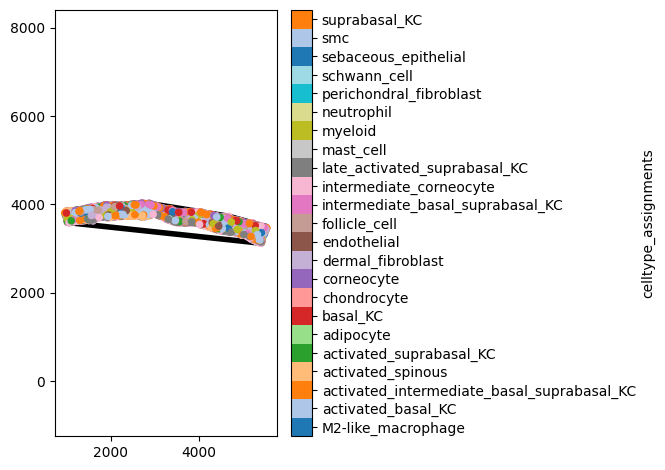

In [5]:
#visualise domains to double check
plt.figure(figsize = (8,5))

for domain in rep_domains.values():
    ms.visualise.visualise(domain, 'celltype_assignments', ax = plt.gca(), show_boundary=True)
    plt.show() 

In [6]:
#calculating network between points
for domain in rep_domains.values():
    ms.networks.generate_network(
        domain,
        network_name='proximity_150',
        network_type='Proximity',
        objects_as_nodes=('collection', 'cells'),
        max_edge_distance=200,
        min_edge_distance=0
    )
    


# #doing the neighbourhood enrichment test
enrichment_outputs = {}

for name, domain in rep_domains.items():
    SES,SES_p_val_filtered,label_categories = ms.networks.adjacency_permutation_test(domain,
                                                                                    network_name='proximity_150',
                                                                                    label_name='celltype_assignments',
                                                                                    alpha=0.05,
                                                                                    label_shuffle_iterations=1000)
    enrichment_outputs[name] = {'SES': SES,
                                'SES_p_val_filtered': SES_p_val_filtered, # |Pz|> 1.96
                                'label_categories': label_categories}


 'neutrophil'] as these have fewer than 15 observations.
 'neutrophil'] as these have fewer than 15 observations.


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

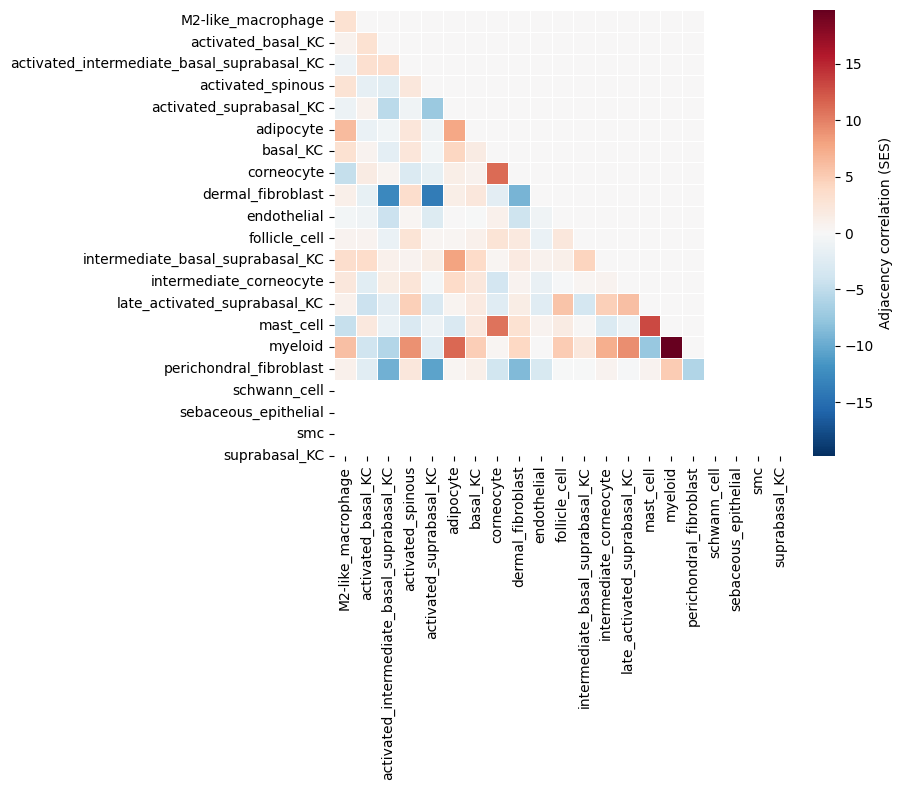

In [7]:
SES = enrichment_outputs['Ctrl_F1']['SES']
len(SES)
ms.visualise.visualise_correlation_matrix(np.tril(SES),label_categories,colorbar_label='Adjacency correlation (SES)')


In [8]:
#now you want a dictionary that for each celltype-pair contains the z-scores, index by condition
#pairwise_Zscores = {'cell1|cell2':{'Ctrl':[z1, z2, z3]}}
pairwise_Zscores = {}

def add_cellpair_z(d, condition):
        for cell1 in d['label_categories']:
            for cell2 in d['label_categories']: 
                #sort in the pair so cell1_cell2/cell2_cell1 are treated the same
                key = '|'.join(sorted([cell1, cell2]))

                x = np.where(d['label_categories'] == cell1)[0]
                y = np.where(d['label_categories'] == cell2)[0]
                value = d['SES'][x, y].item()

                pairwise_Zscores.setdefault(key, {}).setdefault(condition,[]).append(value)

#enrichment_outputs contains name (which is condition_replicateNumber), the SES (standard effect size (correlation) matrix), and labels ordered to align with the matrix. 
for name, d in enrichment_outputs.items():
    if 'Ctrl' in name: #define below as a function with variable being 'condition'.
        add_cellpair_z(d, 'Ctrl')
    elif 'D3IMQ' in name:
        add_cellpair_z(d, 'D3IMQ')
    elif 'D7IMQ' in name:
         add_cellpair_z(d, 'D7IMQ')
    elif 'D10IMQ' in name:
         add_cellpair_z(d, 'D10IMQ')

In [ ]:
import pickle

save_path = "./neighbourhood_results/pairwise_zscores.pkl"

with open(save_path, 'wb') as f:
    pickle.dump(pairwise_Zscores, f)

#to open
with open(save_path, 'rb') as f:
    pairwise_Zscores

{'M2-like_macrophage|M2-like_macrophage': {'Ctrl': [3.0072277171106,
   5.722241579837108,
   1.952209818091814],
  'D10IMQ': [9.100109590708675]},
 'M2-like_macrophage|activated_basal_KC': {'Ctrl': [0.7968861753281111,
   0.7968861753281146,
   -5.342206886362461,
   -5.342206886362459,
   -2.2865012823232562,
   -2.286501282323258],
  'D10IMQ': [6.56190995023917, 6.561909950239181]},
 'M2-like_macrophage|basal_KC': {'Ctrl': [-0.9902042514703969,
   -0.9902042514704038,
   -2.444641987112064,
   -2.4446419871120644,
   -1.248219931591615,
   -1.2482199315916098],
  'D10IMQ': [0.5466314982933177, 0.5466314982933176]},
 'M2-like_macrophage|chondrocyte': {'Ctrl': [2.8821878625796757,
   2.8821878625796757]},
 'M2-like_macrophage|corneocyte': {'Ctrl': [-1.113686327997832,
   -1.1136863279978393,
   -0.9324317685751593,
   -0.9324317685751593,
   2.368682606252283,
   2.368682606252283],
  'D10IMQ': [-6.343353062620736, -6.343353062620735]},
 'M2-like_macrophage|dermal_fibroblast': {'Ctrl'